In [3]:
%load_ext autoreload
%autoreload 2

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.stim_belief_vector_alignment import (
    OUTPUT_PATH, WHOLE_POP, MODE, POOL_FILTERS,
)

plt.rcParams.update({"font.size": 16})

# Stimulus / belief population-vector alignment

Step 2 of `claude_notes/stim_belief_alignment_updated.md`. On correct trials only, relative to a
feature X, three groups:

```
A: X not chosen, X not preferred      B: X chosen, X not preferred      C: X chosen, X preferred
```

and two mean-difference vectors over z-scored activity, with per-unit coordinates concatenated
across sessions:

```
v_stim = r_B1 - r_A     # selection of X, holding belief fixed
v_pref = r_C  - r_B2    # preference for X, holding selection fixed
```

The plot shows `cos(v_stim, v_pref)` against its session-permute shuffle. **H1** (stimulus and
belief codes are disjoint) predicts ~0; **H2** (preference scales the same encoding) predicts > 0.
Error bands are SE across the 12 features.

This replaces the two-contrast analysis in `20260811_visualize_choice_pref_alignment.ipynb`. There
`v_choice` and `v_pref` come from independently filtered pools with their own z-scoring, so the
selection contrast is confounded with belief; here one pool is split three ways, both vectors share
one metric, and each contrast holds the other variable fixed. Computed by
`scripts/pseudo_decoding/belief_partitions/stim_belief_vector_alignment.py`.

## Why group B is halved

B is split into disjoint halves B1, B2, and that is not a refinement -- it is what makes the number
readable. B enters both vectors with opposite signs, so sharing it would put
`E<eps_stim, eps_pref> = -E||e_B||^2` into the numerator: a structurally negative cross-term, worth
about **-0.44 to -0.65** under the null at these trial counts (measured / predicted, Issue 1 of the
note). H1 would then read as strong anti-alignment and H2 as roughly zero -- exactly backwards.
Disjoint halves make that term exactly zero. The check that it worked is the **shuffle sitting near
0** in the summary table at the bottom, rather than near -0.5.

Nothing is subsampled: all ~294 A, all ~65 B (halved), all ~55 C trials per (session, feature). A
mean-difference vector has no need for equal n, so this analysis is deliberately not trial-matched
to the decoding runs.

**One run covers every population.** Each unit's coordinate is computed independently of every
other unit's, so a region is a subset of the same per-unit vectors rather than a separate fit --
`region` is a column in the results, not a separate run directory. Units outside the 6 regions of
interest still count toward `whole_pop`, so the regions do not sum to the whole population.

## How to read the magnitude -- important

**`cos_raw` is not deattenuated, so its value is not a percentage of alignment.** Finite-trial noise
inflates both norms in the denominator, by a factor that varies across time bins, and halving B
makes that worse for both vectors. So:

- read it **only** as a contrast against its own shuffle,
- do **not** read a `cos_raw` of 0.05 as "5% aligned" -- the true value is several-fold larger,
- do **not** compare one time bin, one feature, **or one region** against another as if differences
  in `cos_raw` were differences in alignment.

That last point bites hardest for regions: a region contributes 15-141 units per feature against
382-681 for the whole population, and fewer units means more attenuation. A regional dissociation
claim needs unit-count-matched subsampling first (`choice_pref_axis_geometry.md` shared caveat 3),
which the saved per-unit `*_vectors.pickle` files support without re-running anything.

Unlike the choice_pref analysis, the fix is also available here without a re-run: the compute script
saves per-unit `r_A/r_B1/r_B2/r_C`, their within-group variances `s2_*`, and `n_*` per group, so the
unbiased estimator and the attenuation factors of
`claude_notes/cosine_similarity_debiasing.md` section 5 are a groupby over those files, on the
shuffles as well as the true run. `att_*` answers the question `cos_raw` cannot -- whether a
near-zero cosine means "disjoint codes" (H1) or "no measurable signal in either vector".

Significance bars are the one-sided permutation test of each population against **its own** shuffle
at each timepoint, thicker for smaller p (p < 0.05 / 0.01 / 0.001,
`visualization_utils.SIG_LEVELS`), written by
`scripts/pseudo_decoding/p_val_computations/compute_p_vals_for_stim_belief_align.py`. Significance
*is* comparable across regions; magnitude is not.

In [4]:
# one run per event, unlike the choice_pref analysis: the A/B/C groups fix the pool to correct
# trials, so there is no filter variant to pick between here
RUN_MODE = MODE

SERIES_NAMES = {
    RUN_MODE: "alignment",
    f"{RUN_MODE}_shuffle": "alignment shuffle",
}
SERIES_ORDER = ["alignment", "alignment shuffle"]
SERIES_TO_COLOR = {"alignment": "tab:purple", "alignment shuffle": "#c5b0d5"}
SIG_BAR_SERIES = ["alignment"]

TRIAL_EVENTS = ["StimOnset", "FeedbackOnsetLong"]
# whole population first, then the 6 regions of interest
POPULATIONS = [WHOLE_POP] + list(REGIONS_OF_INTEREST)


def get_args(trial_event):
    """
    Every population lives in one run dir, so region is not part of the naming. The pool filter IS
    part of it -- POOL_FILTERS has to be set or the run dir won't resolve. That differs from the
    choice_pref analysis, where two contrasts with different filters shared a dir and the choice
    contrast's filters rode in the mode name instead.
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject = "both"
    args.mode = RUN_MODE
    args.trial_event = trial_event
    args.base_output_path = OUTPUT_PATH
    args.region_level = None
    args.regions = None
    args.sig_unit_level = None
    args.beh_filters = POOL_FILTERS
    return args


def read_alignment(trial_event, region=None):
    """
    True run plus shuffles, one row per (region, feat, TimeIdx) per run
    """
    res = belief_partitions_io.read_alignment(get_args(trial_event))
    if region is not None:
        res = res[res.region == region]
    res["series"] = res["mode"].map(SERIES_NAMES)
    res["trial_event"] = trial_event
    return res


def read_pvals(trial_event, region):
    """
    Per-timepoint p value of one population against its own shuffle, written by
    p_val_computations/compute_p_vals_for_stim_belief_align.py
    """
    dir = belief_partitions_io.get_dir_name(get_args(trial_event), make_dir=False)
    p_vals = pd.read_pickle(os.path.join(dir, f"{RUN_MODE}_pvals.pickle"))
    return p_vals[p_vals.region == region]

In [5]:
def plot_alignment(region, title=None):
    """
    Both trial events side by side, in the style of visualization_utils.plot_combined_accs
    """
    stim_res = read_alignment("StimOnset", region)
    fb_res = read_alignment("FeedbackOnsetLong", region)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 3.5), sharey="row",
        width_ratios=[stim_res.Time.nunique(), fb_res.Time.nunique()]
    )
    for ax, res in ((ax1, stim_res), (ax2, fb_res)):
        sns.lineplot(
            res, x="Time", y="cos_raw", hue="series", hue_order=SERIES_ORDER,
            palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
        )
        # 0 is what H1 predicts, but it is NOT the null -- the shuffle is
        ax.axhline(y=0, linestyle="dotted", color="black")
        ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    # significance vs. this population's own shuffle, below the traces. Read the shared limits
    # before any bar has a chance to rescale the axes.
    bottom, top = ax1.get_ylim()
    spacing = 0.08 * (top - bottom)
    for ax, trial_event in ((ax1, "StimOnset"), (ax2, "FeedbackOnsetLong")):
        p_vals = read_pvals(trial_event, region)
        for i, series in enumerate(SIG_BAR_SERIES):
            visualization_utils.plot_sig_bars(
                p_vals, bottom - (i + 1) * spacing, ax, color=SERIES_TO_COLOR[series]
            )
    # shared y, so these set both: make room for the bars without rescaling the traces, and keep
    # the ticks on the traces, since a cos_raw tick inside the bar strip reads as data
    ax1.set_ylim(bottom - (len(SIG_BAR_SERIES) + 0.5) * spacing, top)
    ax1.set_yticks([tick for tick in ax1.get_yticks() if bottom <= tick <= top])

    ax1.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
    ax1.set_xlabel("Time to stimuli appear (s)")
    stim_ticks = [-1, -.5, 0, .5, 1]
    ax1.set_xticks(stim_ticks)
    ax1.set_xticklabels(stim_ticks)
    ax1.set_ylabel("cos(v_stim, v_pref)")

    ax2.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax2.set_xlabel("Time to feedback (s)")
    fb_ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
    ax2.set_xticks(fb_ticks)
    ax2.set_xticklabels(fb_ticks)

    visualization_utils.format_plot([ax1, ax2])
    ax1.get_legend().remove()
    ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig, (ax1, ax2), pd.concat((stim_res, fb_res))

## Whole population

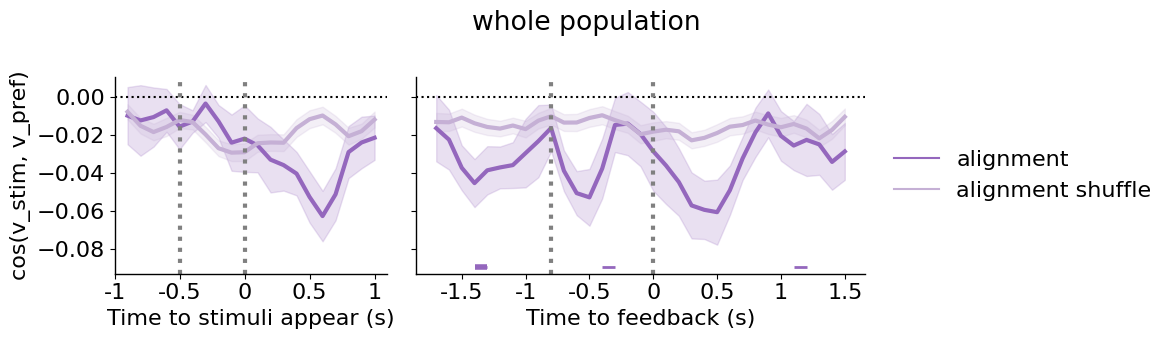

In [6]:
fig, _, whole_pop_res = plot_alignment(WHOLE_POP, title="whole population")

## Regions of interest

Each region against its own shuffle. Recall the y axes are not comparable between regions -- see
the note at the top.

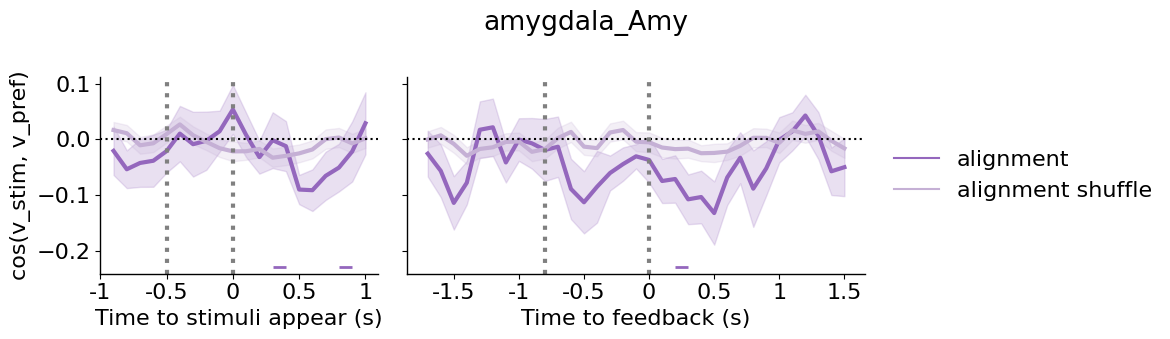

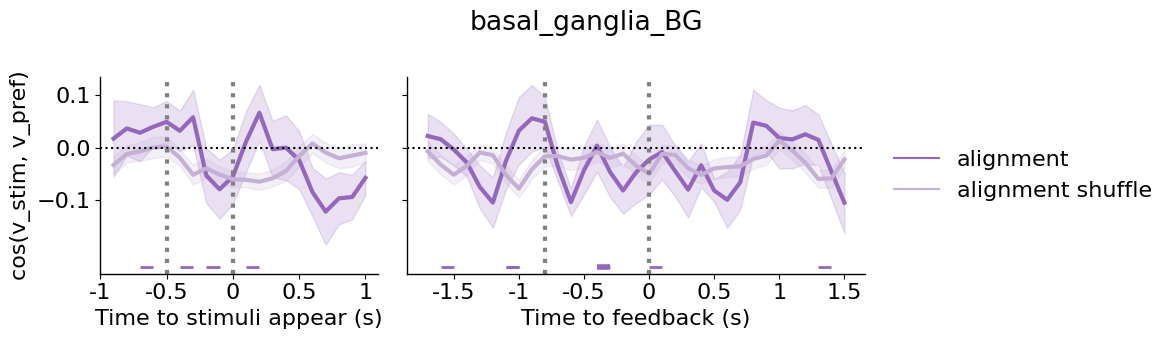

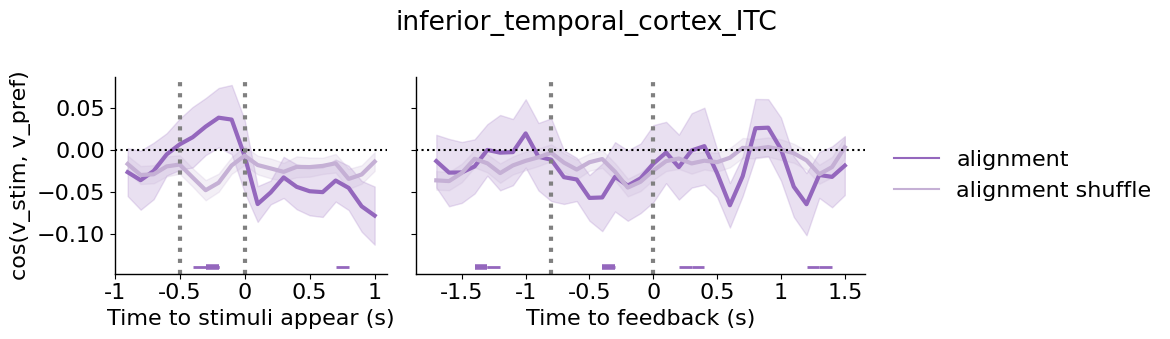

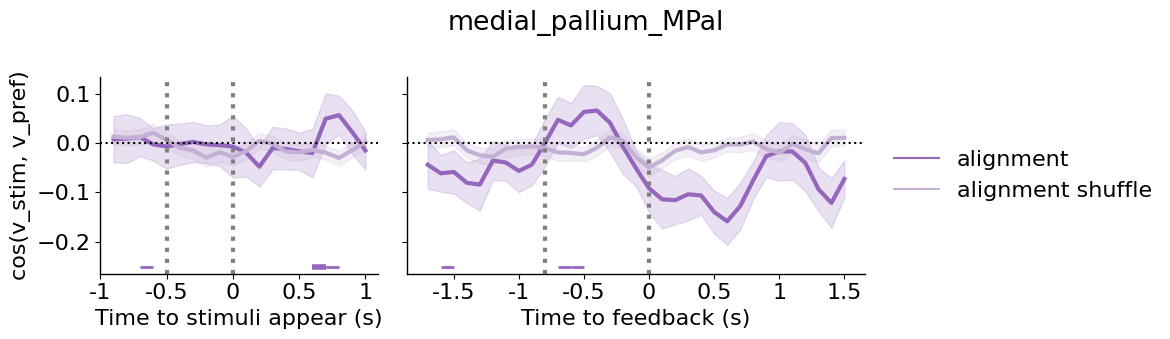

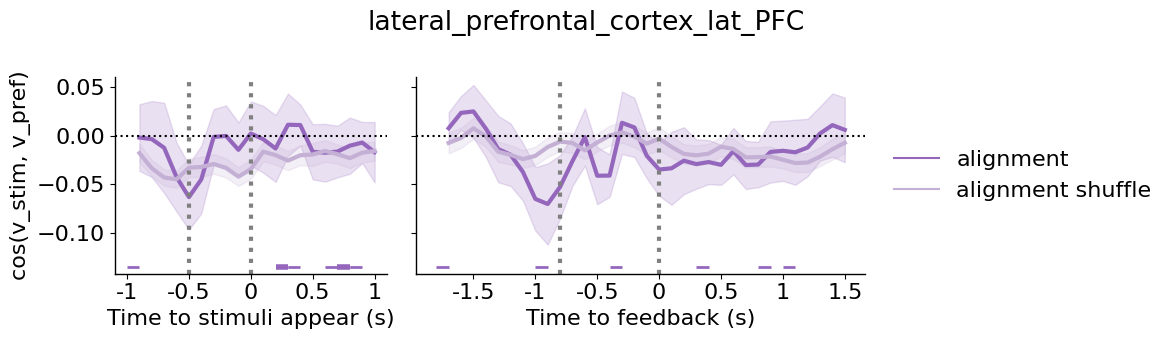

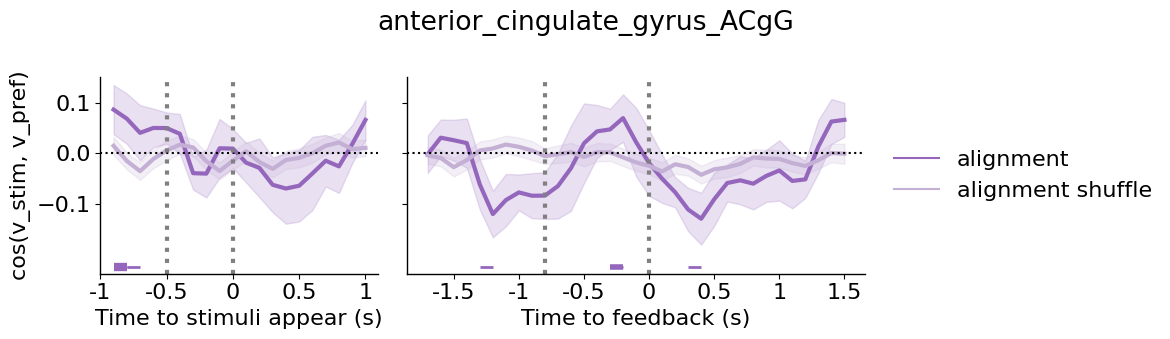

In [7]:
all_res = [whole_pop_res]
for region in POPULATIONS[1:]:
    _, _, res = plot_alignment(region, title=region)
    all_res.append(res)
all_res = pd.concat(all_res)

## Significant timepoints per region

Timepoints where the alignment sits above its own shuffle, one row per population.

In [8]:
sig = []
for trial_event in TRIAL_EVENTS:
    for region in POPULATIONS:
        p = read_pvals(trial_event, region)
        hits = p[p.p < 0.05].Time.to_numpy()
        sig.append({
            "trial_event": trial_event, "region": region,
            "n_sig_bins": len(hits), "n_bins": len(p), "min_p": p.p.min(),
            "sig_window": f"{hits.min():+.1f} to {hits.max():+.1f}" if len(hits) else "-",
            "sig_times": np.round(hits, 1),
        })
sig = pd.DataFrame(sig).set_index(["trial_event", "region"])
sig[["n_sig_bins", "n_bins", "min_p", "sig_window"]]

n_sig_bins  n_bins  \
trial_event       region                                                  
StimOnset         whole_pop                                   0      40   
                  amygdala_Amy                                2      40   
                  basal_ganglia_BG                            4      40   
                  inferior_temporal_cortex_ITC                4      40   
                  medial_pallium_MPal                         3      40   
                  lateral_prefrontal_cortex_lat_PFC           6      40   
                  anterior_cingulate_gyrus_ACgG               2      40   
FeedbackOnsetLong whole_pop                                   3      66   
                  amygdala_Amy                                1      66   
                  basal_ganglia_BG                            6      66   
                  inferior_temporal_cortex_ITC                7      66   
                  medial_pallium_MPal                         3      66   
                  lateral_prefrontal_cortex_lat_PFC           6      66   
                  anterior_cingulate_gyrus_ACgG               3      66   

                                                     min_p    sig_window  
trial_event       region                                                  
StimOnset         whole_pop                          0.054             -  
                  amygdala_Amy                       0.030  +0.4 to +0.9  
                  basal_ganglia_BG                   0.013  -0.6 to +0.2  
                  inferior_temporal_cortex_ITC       0.009  -0.3 to +0.8  
                  medial_pallium_MPal                0.007  -0.6 to +0.8  
                  lateral_prefrontal_cortex_lat_PFC  0.001  -0.9 to +0.9  
                  anterior_cingulate_gyrus_ACgG      0.000  -0.8 to -0.7  
FeedbackOnsetLong whole_pop                          0.007  -1.3 to +1.2  
                  amygdala_Amy                       0.020  +0.3 to +0.3  
                  basal_ganglia_BG                   0.005  -1.5 to +1.4  
                  inferior_temporal_cortex_ITC       0.004  -1.3 to +1.4  
                  medial_pallium_MPal                0.026  -1.5 to -0.5  
                  lateral_prefrontal_cortex_lat_PFC  0.028  -1.7 to +1.1  
                  anterior_cingulate_gyrus_ACgG      0.007  -1.2 to +0.4

In [9]:
# the individual significant timepoints, if the windows above are not contiguous
for (trial_event, region), row in sig.iterrows():
    print(f"{trial_event:18s} {region:34s} {row.sig_times}")

StimOnset          whole_pop                          []
StimOnset          amygdala_Amy                       [0.4 0.9]
StimOnset          basal_ganglia_BG                   [-0.3  0.2 -0.6 -0.1]
StimOnset          inferior_temporal_cortex_ITC       [-0.3 -0.2 -0.2  0.8]
StimOnset          medial_pallium_MPal                [ 0.8 -0.6  0.7]
StimOnset          lateral_prefrontal_cortex_lat_PFC  [-0.9  0.3  0.4  0.7  0.8  0.9]
StimOnset          anterior_cingulate_gyrus_ACgG      [-0.8 -0.7]
FeedbackOnsetLong  whole_pop                          [-1.3 -0.3  1.2]
FeedbackOnsetLong  amygdala_Amy                       [0.3]
FeedbackOnsetLong  basal_ganglia_BG                   [-1.  -1.5 -1.  -0.3  0.1  1.4]
FeedbackOnsetLong  inferior_temporal_cortex_ITC       [-1.3 -1.2 -0.3  0.3  0.4  1.3  1.4]
FeedbackOnsetLong  medial_pallium_MPal                [-0.5 -1.5 -0.6]
FeedbackOnsetLong  lateral_prefrontal_cortex_lat_PFC  [-1.7 -0.9 -0.3  0.4  0.9  1.1]
FeedbackOnsetLong  anterior_cingulate_g

## Summary

Mean `cos_raw` over all time bins, features and runs, and the gap over the shuffle. The **gap** is
the interpretable quantity within a population; absolute levels are attenuated by an unknown factor
that differs between populations, so the `gap` column is not a cross-region ranking either.

Two things to read off the `alignment shuffle` column, before anything else:

1. It should sit **near 0**, not near -0.5. That is the check that the B half-split killed the
   shared-group cross-term -- see the note at the top.
2. It is not exactly 0. That residual is the neural-drift x belief-autocorrelation interaction
   documented in `claude_notes/trial_subselection_autocorrelation_matching.md`, which the split does
   not touch, and it is why the shuffle rather than 0 is the reference the `gap` is taken against.

In [10]:
summary = all_res.groupby(["trial_event", "region", "series"]).cos_raw.mean().unstack("series")
summary["gap"] = summary["alignment"] - summary["alignment shuffle"]
units = all_res[all_res["mode"] == RUN_MODE].groupby(["trial_event", "region"]).n_units.agg(["min", "max"])
summary = summary.join(units.rename(columns={"min": "units_min", "max": "units_max"}))
summary = summary.reindex(TRIAL_EVENTS, level="trial_event").reindex(POPULATIONS, level="region")
summary.round(4)

alignment  \
trial_event       region                                         
StimOnset         whole_pop                            -0.0254   
                  amygdala_Amy                         -0.0218   
                  basal_ganglia_BG                     -0.0163   
                  inferior_temporal_cortex_ITC         -0.0246   
                  medial_pallium_MPal                  -0.0002   
                  lateral_prefrontal_cortex_lat_PFC    -0.0132   
                  anterior_cingulate_gyrus_ACgG         0.0020   
FeedbackOnsetLong whole_pop                            -0.0328   
                  amygdala_Amy                         -0.0469   
                  basal_ganglia_BG                     -0.0253   
                  inferior_temporal_cortex_ITC         -0.0204   
                  medial_pallium_MPal                  -0.0524   
                  lateral_prefrontal_cortex_lat_PFC    -0.0183   
                  anterior_cingulate_gyrus_ACgG        -0.0308   

                                                     alignment shuffle  \
trial_event       region                                                 
StimOnset         whole_pop                                    -0.0182   
                  amygdala_Amy                                 -0.0067   
                  basal_ganglia_BG                             -0.0281   
                  inferior_temporal_cortex_ITC                 -0.0237   
                  medial_pallium_MPal                          -0.0079   
                  lateral_prefrontal_cortex_lat_PFC            -0.0268   
                  anterior_cingulate_gyrus_ACgG                -0.0041   
FeedbackOnsetLong whole_pop                                    -0.0153   
                  amygdala_Amy                                 -0.0065   
                  basal_ganglia_BG                             -0.0285   
                  inferior_temporal_cortex_ITC                 -0.0158   
                  medial_pallium_MPal                          -0.0105   
                  lateral_prefrontal_cortex_lat_PFC            -0.0129   
                  anterior_cingulate_gyrus_ACgG                -0.0105   

                                                        gap  units_min  \
trial_event       region                                                 
StimOnset         whole_pop                         -0.0072        382   
                  amygdala_Amy                      -0.0151         21   
                  basal_ganglia_BG                   0.0117         15   
                  inferior_temporal_cortex_ITC      -0.0009         42   
                  medial_pallium_MPal                0.0077         29   
                  lateral_prefrontal_cortex_lat_PFC  0.0136         68   
                  anterior_cingulate_gyrus_ACgG      0.0061         19   
FeedbackOnsetLong whole_pop                         -0.0175        382   
                  amygdala_Amy                      -0.0404         21   
                  basal_ganglia_BG                   0.0032         15   
                  inferior_temporal_cortex_ITC      -0.0046         42   
                  medial_pallium_MPal               -0.0419         29   
                  lateral_prefrontal_cortex_lat_PFC -0.0054         68   
                  anterior_cingulate_gyrus_ACgG     -0.0203         19   

                                                     units_max  
trial_event       region                                        
StimOnset         whole_pop                                681  
                  amygdala_Amy                              54  
                  basal_ganglia_BG                          47  
                  inferior_temporal_cortex_ITC             114  
                  medial_pallium_MPal                       72  
                  lateral_prefrontal_cortex_lat_PFC        141  
                  anterior_cingulate_gyrus_ACgG             50  
FeedbackOnsetLong whole_pop              

# Cross-validated cosine (`cos_cv`)

Everything above is `cos_raw`, whose numerator is unbiased but whose **denominators are not** -- the
"How to read the magnitude" warning at the top. `cos_cv` is section 4 of
`claude_notes/cosine_similarity_debiasing.md`, and it fixes the denominators by cross-validation
rather than by modelling the noise. A, B **and** C are each halved, giving four half-vectors per
repeat,

```
v_stim^h = r_Bh - r_Ah        v_pref^h = r_Ch - r_Bh        h in {1, 2}
```

and all three pieces are formed across independent halves, so no group mean is ever multiplied by
itself:

```
num     = 1/2 (<v_stim^1, v_pref^2> + <v_stim^2, v_pref^1>)
sq_stim = <v_stim^1, v_stim^2>            sq_pref = <v_pref^1, v_pref^2>
cos_cv  = num / sqrt(sq_stim * sq_pref)
```

`sq_stim` and `sq_pref` estimate the squared norms with the noise power removed, so unlike
`cos_raw`, `cos_cv`'s **time-course shape and cross-region comparisons are not distorted by an
attenuation factor that varies with trial count**. The compute script averages the pieces over
`--num_cv_repeats` half-splits and saves them per unit, so pooling them here is a groupby.

## Pooling rule: ratio of sums, never a mean of cosines

The pieces are inner products, so a population's `cos_cv` is a sum over its units and features
divided **once**. Averaging the per-`(feat, bin)` `cos_cv` column instead -- which is exactly what
`sns.lineplot(y="cos_cv", errorbar="se")` would do -- is a mean of ratios, and the difference is not
cosmetic here: at these trial counts `sq_stim` or `sq_pref` comes out non-positive in roughly 44% of
`(region, feat, bin)` rows (measured on SA/StimOnset), and among the rows that survive, those whose
denominator landed near zero dominate the average. Dropping the non-positive ones is worse than it
looks, because the numerator shares half its trials with the denominators, so that selection is not
independent of the quantity being measured.

The traces below are therefore pooled over the 12 features at each timepoint, and the band is a
**delete-one-feature jackknife** rather than an SE across features -- the standard spread for a
ratio estimator, and it answers the same question the `cos_raw` bands do: how much of this trace
rides on a single feature.

## What `cos_cv` still does not fix

It removes the two finite-trial biases and nothing else. Trials are not independent: the population
drifts across a session and belief is block-autocorrelated, so A, B and C occupy different stretches
of that drift, and a random within-group half-split interleaves the halves in time and is blind to
it (`claude_notes/trial_subselection_autocorrelation_matching.md`). Measured on SA/StimOnset that
term is **live** -- the shuffle sits near -0.21 rather than at 0, because `session_permute` imports a
donor session's block structure and so reproduces the confound by construction, which is what makes
it the right null for it. **Read the gap against the shuffle, not the absolute level.**

No significance bars here. The p-value script guards `cos_cv` on attenuation (recommendation 3 of
the debiasing note, `att >= 0.3`) and at these trial counts too few rows clear the guard for a
per-timepoint test to mean anything, so it reports `cos_cv` as not tested rather than emitting
selection-driven p-values.

In [11]:
# the three pieces cos_cv is a ratio of, and the two self-products that give the attenuation
CV_PIECES = ["cv_num", "cv_sq_stim", "cv_sq_pref"]
CV_SS = ["cv_ss_stim", "cv_ss_pref"]


def require_cv_columns(res):
    """
    The cv_* columns only exist in runs made after cos_cv shipped.

    The same change re-derived the B half-split seed, so a directory holding a mix of old and new
    files is not just missing columns -- its true run and its shuffles would be on two different
    splits. Hence "re-run the whole grid", not "re-run what's missing".
    """
    missing = [c for c in CV_PIECES + CV_SS if c not in res.columns]
    if missing:
        raise KeyError(
            f"{missing} missing from the alignment summary -- this run predates cos_cv. Re-run "
            "stim_belief_vector_alignment.py over the FULL --run_all grid (both events, true run "
            "and all shuffles) so every file comes from one B half-split seed."
        )


def cos_cv_from(pieces):
    """
    cos_cv from already-summed pieces. NaN unless BOTH squared norms are positive: two negative
    ones multiply to a positive product and a sign-flipped cosine, so the product alone is not a
    sufficient check.
    """
    num, sq_stim, sq_pref = (pieces[k] for k in CV_PIECES)
    if not (sq_stim > 0 and sq_pref > 0):
        return np.nan
    return num / np.sqrt(sq_stim * sq_pref)


def cos_cv_by_time(res):
    """
    Pooled cos_cv per (series, Time), with a delete-one-feature jackknife SE.

    Pooling means summing the three pieces over every unit and feature and dividing once -- see the
    markdown above for why averaging the per-(feat, bin) cos_cv column instead is not an option.
    That leaves no per-feature sample to take an SE over, so the band comes from re-pooling with
    each feature dropped in turn: se = sqrt((n-1)/n * sum_f (theta_-f - mean(theta_-f))^2).
    """
    rows = []
    for (series, time), group in res.groupby(["series", "Time"]):
        by_feat = group.groupby("feat")[CV_PIECES].sum()
        total = by_feat.sum()
        # leave-one-feature-out is the total minus that feature's contribution, since the pieces
        # are sums -- no need to re-group 12 times
        loo = np.array([cos_cv_from(total - by_feat.loc[feat]) for feat in by_feat.index])
        n = np.isfinite(loo).sum()
        se = np.sqrt((n - 1) / n * np.nansum((loo - np.nanmean(loo)) ** 2)) if n > 1 else np.nan
        rows.append({
            "series": series, "Time": time, "cos_cv": cos_cv_from(total), "se": se,
            "n_feats": len(by_feat), "n_feats_jackknife": int(n),
        })
    return pd.DataFrame(rows).sort_values(["series", "Time"])


def plot_alignment_cv(region, title=None):
    """
    cos_cv for both trial events, in the same layout as plot_alignment.

    Traces are precomputed rather than handed to sns.lineplot, because the y value is a ratio of
    sums over the features rather than a mean over them. No significance bars -- see the markdown.
    """
    stim_res = read_alignment("StimOnset", region)
    fb_res = read_alignment("FeedbackOnsetLong", region)
    require_cv_columns(stim_res)

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 3.5), sharey="row",
        width_ratios=[stim_res.Time.nunique(), fb_res.Time.nunique()]
    )
    for ax, res in ((ax1, stim_res), (ax2, fb_res)):
        by_time = cos_cv_by_time(res)
        for series in SERIES_ORDER:
            trace = by_time[by_time.series == series]
            ax.plot(trace.Time, trace.cos_cv, color=SERIES_TO_COLOR[series], linewidth=3,
                    label=series)
            ax.fill_between(trace.Time, trace.cos_cv - trace.se, trace.cos_cv + trace.se,
                            color=SERIES_TO_COLOR[series], alpha=0.25, linewidth=0)
        # 0 is what H1 predicts, but it is NOT the null -- the shuffle is, and here it sits well
        # away from 0 (drift x belief autocorrelation), so the vertical gap is the whole readout
        ax.axhline(y=0, linestyle="dotted", color="black")
        ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    ax1.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
    ax1.set_xlabel("Time to stimuli appear (s)")
    stim_ticks = [-1, -.5, 0, .5, 1]
    ax1.set_xticks(stim_ticks)
    ax1.set_xticklabels(stim_ticks)
    ax1.set_ylabel("cos_cv(v_stim, v_pref)")

    ax2.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax2.set_xlabel("Time to feedback (s)")
    fb_ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
    ax2.set_xticks(fb_ticks)
    ax2.set_xticklabels(fb_ticks)

    visualization_utils.format_plot([ax1, ax2])
    ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig, (ax1, ax2), pd.concat((stim_res, fb_res))

## Whole population -- `cos_cv`

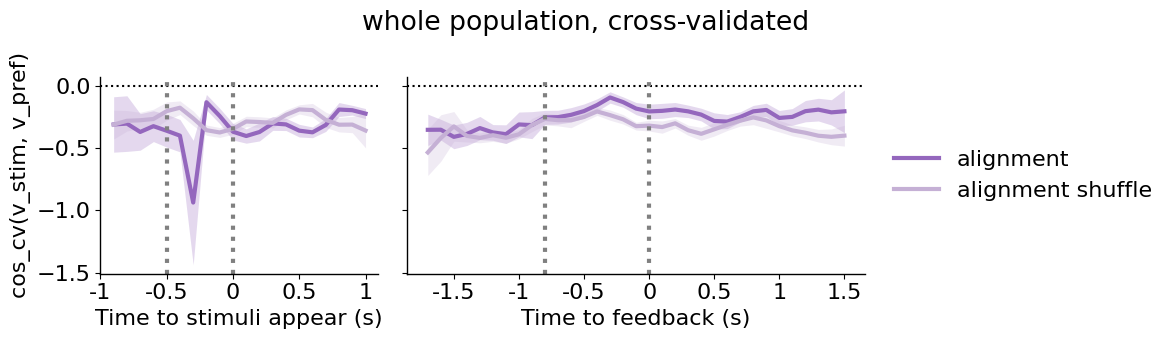

In [12]:
fig, _, whole_pop_res_cv = plot_alignment_cv(WHOLE_POP, title="whole population, cross-validated")

## Regions of interest -- `cos_cv`

Each region against its own shuffle. Unlike `cos_raw`, the y axes here are *in principle* comparable
across regions -- removing the noise power from both norms is exactly what removes the unit-count
dependence that made `cos_raw` incomparable. Two caveats before using that:

1. a region's `sq_stim` / `sq_pref` are differences of large noisy numbers over far fewer units, so
   its traces are much noisier and can go undefined (gaps in the line) where a squared norm came out
   non-positive,
2. the drift term is not removed, and there is no reason it is the same size in every region.

Check the `att_stim` / `att_pref` columns in the summary below before reading any regional
difference: a region whose attenuation is near zero has no measurable signal in that vector, and its
`cos_cv` is a ratio of two small noisy numbers rather than a measurement.

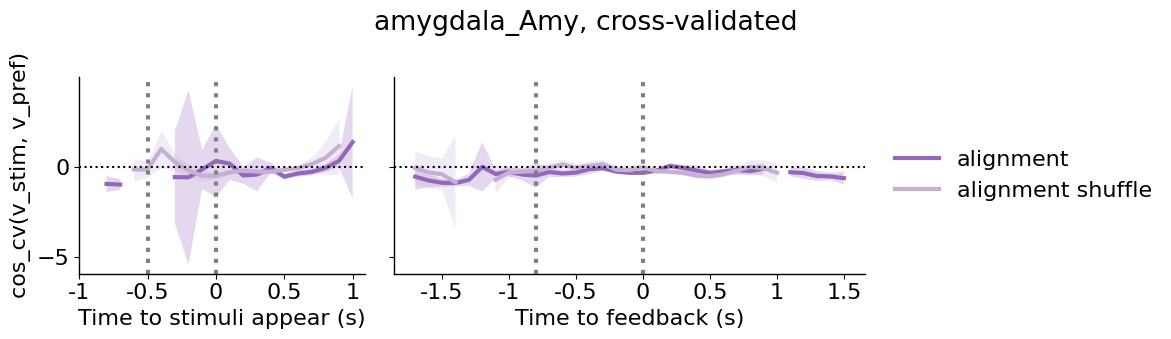

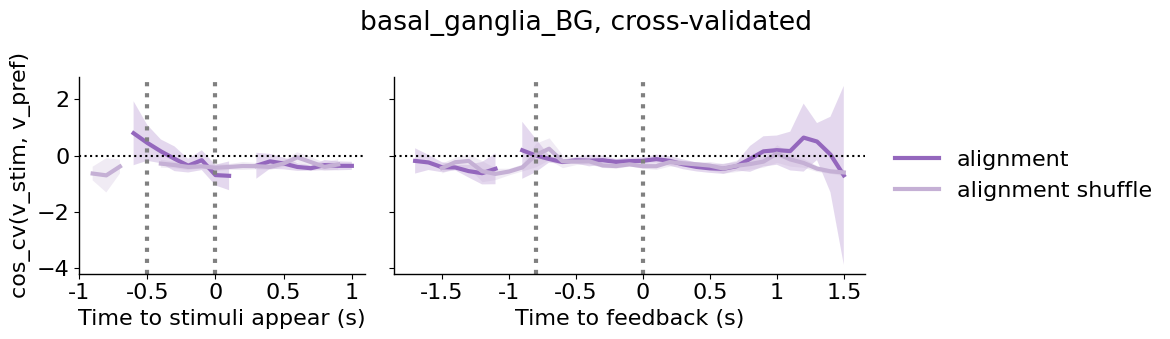

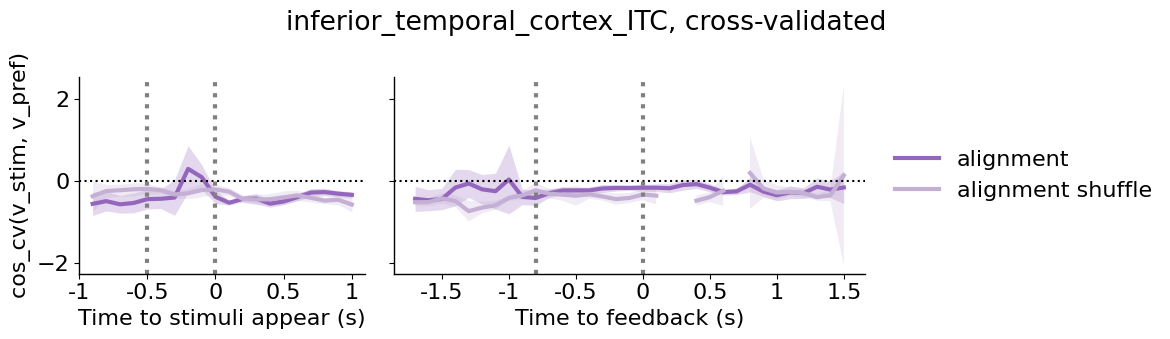

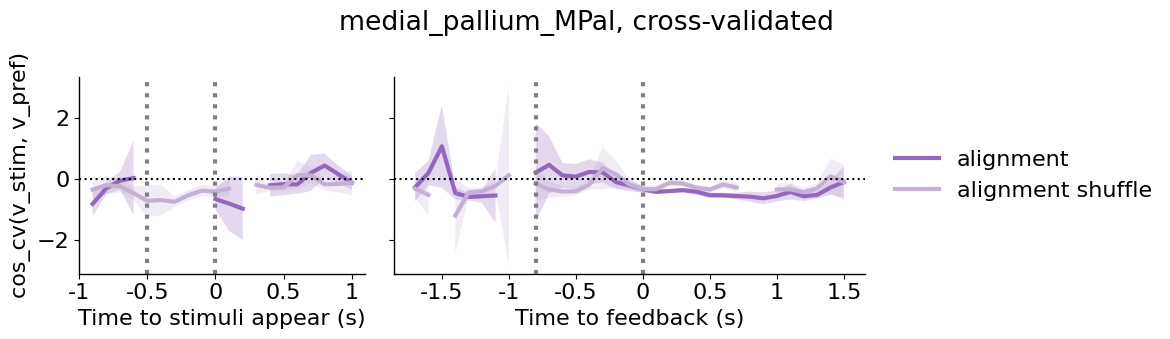

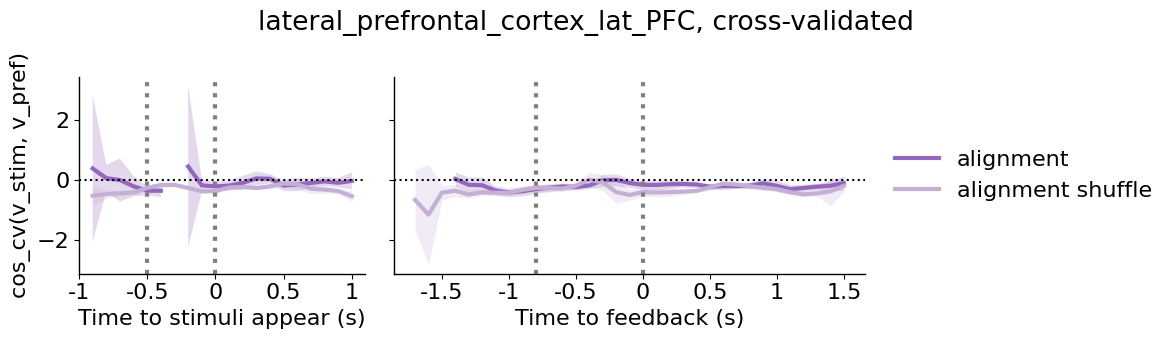

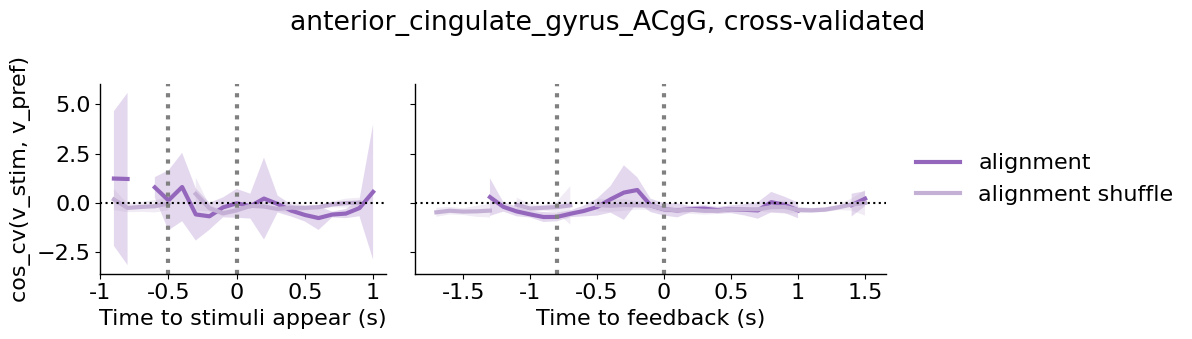

In [13]:
all_res_cv = [whole_pop_res_cv]
for region in POPULATIONS[1:]:
    _, _, res = plot_alignment_cv(region, title=f"{region}, cross-validated")
    all_res_cv.append(res)
all_res_cv = pd.concat(all_res_cv)

## Summary -- `cos_cv`

`cos_cv` pooled over every time bin, feature, unit and run, as a ratio of sums, with the gap over
the shuffle. As with `cos_raw` the **gap** is the interpretable quantity, because the drift term
survives cross-validation and sits in both series.

The extra columns are the point of the whole exercise:

- **`att_stim` / `att_pref`** -- `sqrt(sq / ss)`, the fraction of each vector's power that is signal
  rather than noise. This is what `cos_raw` cannot tell you: whether a near-zero cosine means
  "disjoint codes" (H1) or "no measurable signal in either vector", which is the tie the ITC
  argument in `weight_vs_mean_difference_axes.md` section 7 turns on. Measured on the **half**
  vectors, which carry about twice the noise power of the full-data ones, so the corresponding
  full-data factor is `sqrt(sq / (sq + (ss - sq) / 2))` -- i.e. these are pessimistic.
- **`frac_defined`** -- the fraction of per-`(feat, bin)` rows whose own `cos_cv` was defined. Low
  here is expected and is why the traces above are pooled rather than averaged; it is also why the
  p-value script declines to test `cos_cv` per timepoint.

In [14]:
# sum the pieces over everything being pooled, then divide once -- the same rule the traces follow
pooled_cv = all_res_cv.groupby(["trial_event", "region", "series"])[CV_PIECES + CV_SS].sum()
defined = (pooled_cv.cv_sq_stim > 0) & (pooled_cv.cv_sq_pref > 0)
pooled_cv["cos_cv"] = (
    pooled_cv.cv_num / np.sqrt(pooled_cv.cv_sq_stim * pooled_cv.cv_sq_pref)
).where(defined)
for vec in ("stim", "pref"):
    pooled_cv[f"att_{vec}"] = np.sqrt(
        pooled_cv[f"cv_sq_{vec}"].clip(lower=0) / pooled_cv[f"cv_ss_{vec}"]
    )

summary_cv = pooled_cv["cos_cv"].unstack("series")
summary_cv["gap"] = summary_cv["alignment"] - summary_cv["alignment shuffle"]
# attenuation is a property of the true run's vectors, so the shuffle's copy is not informative here
summary_cv = summary_cv.join(pooled_cv.xs("alignment", level="series")[["att_stim", "att_pref"]])
summary_cv["frac_defined"] = (
    all_res_cv[all_res_cv["mode"] == RUN_MODE]
    .groupby(["trial_event", "region"]).cos_cv.apply(lambda col: col.notna().mean())
)
summary_cv = summary_cv.reindex(TRIAL_EVENTS, level="trial_event").reindex(POPULATIONS, level="region")
summary_cv.round(4)

alignment  \
trial_event       region                                         
StimOnset         whole_pop                            -0.2748   
                  amygdala_Amy                         -0.2411   
                  basal_ganglia_BG                     -0.2396   
                  inferior_temporal_cortex_ITC         -0.3361   
                  medial_pallium_MPal                  -0.2061   
                  lateral_prefrontal_cortex_lat_PFC    -0.0912   
                  anterior_cingulate_gyrus_ACgG        -0.1724   
FeedbackOnsetLong whole_pop                            -0.2085   
                  amygdala_Amy                         -0.2757   
                  basal_ganglia_BG                     -0.1899   
                  inferior_temporal_cortex_ITC         -0.1781   
                  medial_pallium_MPal                  -0.3057   
                  lateral_prefrontal_cortex_lat_PFC    -0.1758   
                  anterior_cingulate_gyrus_ACgG        -0.2684   

                                                     alignment shuffle  \
trial_event       region                                                 
StimOnset         whole_pop                                    -0.2801   
                  amygdala_Amy                                 -0.0477   
                  basal_ganglia_BG                             -0.3283   
                  inferior_temporal_cortex_ITC                 -0.3072   
                  medial_pallium_MPal                          -0.3204   
                  lateral_prefrontal_cortex_lat_PFC            -0.2903   
                  anterior_cingulate_gyrus_ACgG                -0.1546   
FeedbackOnsetLong whole_pop                                    -0.3282   
                  amygdala_Amy                                 -0.1909   
                  basal_ganglia_BG                             -0.3310   
                  inferior_temporal_cortex_ITC                 -0.3665   
                  medial_pallium_MPal                          -0.2768   
                  lateral_prefrontal_cortex_lat_PFC            -0.3193   
                  anterior_cingulate_gyrus_ACgG                -0.2792   

                                                        gap  att_stim  \
trial_event       region                                                
StimOnset         whole_pop                          0.0053    0.2828   
                  amygdala_Amy                      -0.1934    0.2245   
                  basal_ganglia_BG                   0.0886    0.2885   
                  inferior_temporal_cortex_ITC      -0.0290    0.3421   
                  medial_pallium_MPal                0.1143    0.1938   
                  lateral_prefrontal_cortex_lat_PFC  0.1990    0.2153   
                  anterior_cingulate_gyrus_ACgG     -0.0178    0.1767   
FeedbackOnsetLong whole_pop                          0.1197    0.4003   
                  amygdala_Amy                      -0.0848    0.3963   
                  basal_ganglia_BG                   0.1411    0.3967   
                  inferior_temporal_cortex_ITC       0.1884    0.4768   
                  medial_pallium_MPal               -0.0289    0.3563   
                  lateral_prefrontal_cortex_lat_PFC  0.1435    0.3450   
                  anterior_cingulate_gyrus_ACgG      0.0108    0.1949   

                                                     att_pref  frac_defined  
trial_event       region                                                     
StimOnset         whole_pop                            0.3296        0.8375  
                  amygdala_Amy                         0.2819        0.4667  
                  basal_ganglia_BG                     0.3522        0.5500  
                  inferior_temporal_cortex_ITC         0.3298        0.7042  
                  medial_pallium_MPal                  0.3385        0.5250  
                  lateral_prefrontal_cortex_lat_PFC    0.3505        0.6333  
                  